In [1]:
from statsmodels.tsa.x13 import x13_arima_analysis
from sympy import *
init_printing()
from IPython.display import Math
from sympy import Rational as R

# Sample mean and covariance matrix

In [2]:
X1 = Matrix([1, 2, 1])
X2 = Matrix([4, 2, 13])
X3 = Matrix([7, 8, 1])
X4 = Matrix([8, 4, 5])

In [4]:
# sample mean
N = 4
M = (1/N)*(X1 + X2 + X3 + X4)
M

⎡5.0⎤
⎢   ⎥
⎢4.0⎥
⎢   ⎥
⎣5.0⎦

In [5]:
X1_bar = X1 - M
X2_bar = X2 - M
X3_bar = X3 - M
X4_bar = X4 - M

In [6]:
B = Matrix.hstack(X1_bar, X2_bar, X3_bar, X4_bar)
B

⎡-4.0  -1.0  2.0   3.0⎤
⎢                     ⎥
⎢-2.0  -2.0  4.0    0 ⎥
⎢                     ⎥
⎣-4.0  8.0   -4.0   0 ⎦

In [11]:
S = (1/(N-1)) * (B * B.T)
S

⎡10.0  6.0    0  ⎤
⎢                ⎥
⎢6.0   8.0   -8.0⎥
⎢                ⎥
⎣ 0    -8.0  32.0⎦

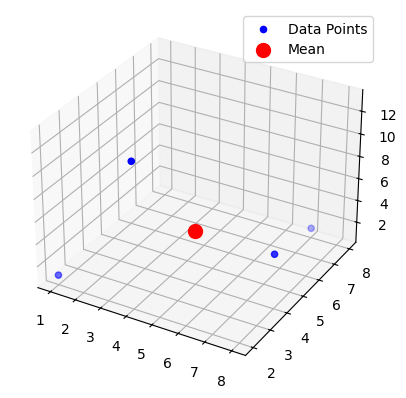

In [15]:
# plot data points, then the principal components as arrows from the mean
import matplotlib.pyplot as plt
# Convert sympy objects to floats for plotting
X1_f = [float(X1[0]), float(X1[1]), float(X1[2])]
X2_f = [float(X2[0]), float(X2[1]), float(X2[2])]
X3_f = [float(X3[0]), float(X3[1]), float(X3[2])]
X4_f = [float(X4[0]), float(X4[1]), float(X4[2])]
M_f = [float(M[0]), float(M[1]), float(M[2])]

# Plot data points and the mean
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter([X1_f[0], X2_f[0], X3_f[0], X4_f[0]],
           [X1_f[1], X2_f[1], X3_f[1], X4_f[1]],
           [X1_f[2], X2_f[2], X3_f[2], X4_f[2]], color='b', label='Data Points')
ax.scatter([M_f[0]], [M_f[1]], [M_f[2]], color='r', s=100, label='Mean')
ax.legend()
plt.show()

# PCA

In [48]:
S = Matrix([[2382.78, 2611.84, 2136.20], [2611.84, 3106.47, 2553.90], [2136.20, 2553.90, 2650.71]])
eigenvectors = S.eigenvects()
eigenvectors

⎡⎛                     ⎡⎡0.541729504226801⎤⎤⎞  ⎛                     ⎡⎡0.68341 ↪
⎢⎜                     ⎢⎢                 ⎥⎥⎟  ⎜                     ⎢⎢        ↪
⎢⎜7614.23008449027, 1, ⎢⎢0.62947576355966 ⎥⎥⎟, ⎜98.1048093384954, 1, ⎢⎢-0.7156 ↪
⎢⎜                     ⎢⎢                 ⎥⎥⎟  ⎜                     ⎢⎢        ↪
⎣⎝                     ⎣⎣0.55703627111811 ⎦⎦⎠  ⎝                     ⎣⎣ 0.1441 ↪

↪ 4482307915 ⎤⎤⎞  ⎛                     ⎡⎡-0.489360592632865⎤⎤⎞⎤
↪            ⎥⎥⎟  ⎜                     ⎢⎢                  ⎥⎥⎟⎥
↪ 67237349577⎥⎥⎟, ⎜427.625106171235, 1, ⎢⎢-0.302622980745692⎥⎥⎟⎥
↪            ⎥⎥⎟  ⎜                     ⎢⎢                  ⎥⎥⎟⎥
↪ 0083537658 ⎦⎦⎠  ⎝                     ⎣⎣0.817890910759255 ⎦⎦⎠⎦

In [49]:
l1 = eigenvectors[0][0]
l2 = eigenvectors[2][0]
l3 = eigenvectors[1][0]
l1, l2, l3

In [50]:
v1 = eigenvectors[0][2][0]
v2 = eigenvectors[2][2][0]
v3 = eigenvectors[1][2][0]
v1, v2, v3

⎛⎡0.541729504226801⎤  ⎡-0.489360592632865⎤  ⎡0.683414482307915 ⎤⎞
⎜⎢                 ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎜⎢0.62947576355966 ⎥, ⎢-0.302622980745692⎥, ⎢-0.715667237349577⎥⎟
⎜⎢                 ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎝⎣0.55703627111811 ⎦  ⎣0.817890910759255 ⎦  ⎣ 0.14410083537658 ⎦⎠

In [51]:
x1, x2, x3 = symbols('x1 x2 x3')
# approximate v1, v2, v3 as numerical vectors
v1 = v1.evalf(2)
v2 = v2.evalf(2)
v3 = v3.evalf(2)

PC1 = v1[0]*x1 + v1[1]*x2 + v1[2]*x3
PC2 = v2[0]*x1 + v2[1]*x2 + v2[2]*x3
PC3 = v3[0]*x1 + v3[1]*x2 + v3[2]*x3
PC1, PC2, PC3

In [52]:
l1 = l1.round(2)
l2 = l2.round(2)
l3 = l3.round(2)

D = Matrix([[l1, 0, 0], [0, l2, 0], [0, 0, l3]])
D

⎡7614.23    0      0  ⎤
⎢                     ⎥
⎢   0     427.63   0  ⎥
⎢                     ⎥
⎣   0       0     98.1⎦

In [53]:
trace = l1 + l2 + l3
trace

In [55]:
explained1 = ((l1 / trace)*100).round(1)
explained2 = ((l2 / trace)*100).round(1)
explained3 = ((l3 / trace)*100).round(1)
explained1, explained2, explained3